In [1]:
# Cell 1 — Install dependencies
!pip install pytorch-lightning==1.9.5 -q

import os, sys, glob, yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

print(f"PyTorch: {torch.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.5/829.5 kB 37.3 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
GPU: Tesla T4


In [2]:
# Cell 2 — Clone repo and apply all patches
!git clone https://github.com/AntixK/PyTorch-VAE /kaggle/working/PyTorch-VAE
os.chdir('/kaggle/working/PyTorch-VAE')

# ── Patch dataset.py ──
dataset_patch = '''import os
import torch
from PIL import Image
from typing import Optional
from torch.utils.data import Dataset, DataLoader, random_split
import pytorch_lightning as pl
from torchvision import transforms

class CelebACustom(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.imgs = sorted(os.listdir(img_dir))
        self.transform = transform
    def __len__(self):
        return len(self.imgs)
    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.img_dir, self.imgs[idx])).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0

class VAEDataset(pl.LightningDataModule):
    def __init__(self, data_path, train_batch_size=64, val_batch_size=64,
                 patch_size=64, num_workers=2, pin_memory=False, **kwargs):
        super().__init__()
        self.img_dir = os.path.join(data_path, "img_align_celeba", "img_align_celeba")
        self.train_batch_size = train_batch_size
        self.val_batch_size   = val_batch_size
        self.patch_size       = patch_size
        self.num_workers      = num_workers
        self.pin_memory       = pin_memory

    def setup(self, stage=None):
        transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.CenterCrop(148),
            transforms.Resize(self.patch_size),
            transforms.ToTensor(),
        ])
        full    = CelebACustom(self.img_dir, transform=transform)
        n       = len(full)
        n_train = int(0.8 * n)
        n_val   = int(0.1 * n)
        n_test  = n - n_train - n_val
        self.train_dataset, self.val_dataset, self.test_dataset = \
            random_split(full, [n_train, n_val, n_test],
                         generator=torch.Generator().manual_seed(42))

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.train_batch_size,
                          shuffle=True, num_workers=self.num_workers, pin_memory=self.pin_memory)
    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.val_batch_size,
                          shuffle=False, num_workers=self.num_workers, pin_memory=self.pin_memory)
    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.val_batch_size,
                          shuffle=False, num_workers=self.num_workers, pin_memory=self.pin_memory)
'''
with open('dataset.py', 'w') as f: f.write(dataset_patch)

# ── Patch experiment.py ──
experiment_patch = '''import os
import torch
from torch import optim
from models import BaseVAE
from models.types_ import *
from utils import data_loader
import pytorch_lightning as pl
from torchvision import transforms
import torchvision.utils as vutils
from torchvision.datasets import CelebA
from torch.utils.data import DataLoader

class VAEXperiment(pl.LightningModule):
    def __init__(self, vae_model: BaseVAE, params: dict) -> None:
        super(VAEXperiment, self).__init__()
        self.model = vae_model
        self.params = params
        self.curr_device = None
        self.hold_graph = False
        try:
            self.hold_graph = self.params["retain_first_backpass"]
        except: pass

    def forward(self, input: Tensor, **kwargs) -> Tensor:
        return self.model(input, **kwargs)

    def training_step(self, batch, batch_idx):
        real_img, labels = batch
        self.curr_device = real_img.device
        results = self.forward(real_img, labels=labels)
        train_loss = self.model.loss_function(*results,
                        M_N=self.params["kld_weight"], batch_idx=batch_idx)
        self.log_dict({key: val.item() for key, val in train_loss.items()}, sync_dist=True)
        return train_loss["loss"]

    def validation_step(self, batch, batch_idx):
        real_img, labels = batch
        self.curr_device = real_img.device
        results = self.forward(real_img, labels=labels)
        val_loss = self.model.loss_function(*results, M_N=1.0, batch_idx=batch_idx)
        self.log_dict({f"val_{key}": val.item() for key, val in val_loss.items()}, sync_dist=True)

    def on_validation_end(self) -> None:
        self.sample_images()

    def sample_images(self):
        test_input, test_label = next(iter(self.trainer.datamodule.test_dataloader()))
        test_input = test_input.to(self.curr_device)
        test_label = test_label.to(self.curr_device)
        recons = self.model.generate(test_input, labels=test_label)
        os.makedirs(f"{self.logger.log_dir}/Reconstructions/", exist_ok=True)
        vutils.save_image(recons.data,
                          os.path.join(self.logger.log_dir, "Reconstructions",
                          f"recons_{self.logger.name}_Epoch_{self.current_epoch}.png"),
                          normalize=True, nrow=12)
        try:
            samples = self.model.sample(144, self.curr_device, labels=test_label)
            os.makedirs(f"{self.logger.log_dir}/Samples/", exist_ok=True)
            vutils.save_image(samples.cpu().data,
                              os.path.join(self.logger.log_dir, "Samples",
                              f"{self.logger.name}_Epoch_{self.current_epoch}.png"),
                              normalize=True, nrow=12)
        except Warning: pass

    def configure_optimizers(self):
        optimizer = optim.Adam(self.model.parameters(),
                               lr=self.params["LR"],
                               weight_decay=self.params.get("weight_decay", 0))
        scheduler = optim.lr_scheduler.ExponentialLR(
            optimizer, gamma=self.params.get("scheduler_gamma", 0.95))
        return [optimizer], [scheduler]
'''
with open('experiment.py', 'w') as f: f.write(experiment_patch)

# ── Patch run.py ──
run_patch = '''import os, yaml, argparse, glob
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from models import vae_models
from experiment import VAEXperiment
from dataset import VAEDataset

parser = argparse.ArgumentParser()
parser.add_argument("--config", "-c", dest="filename", default="configs/vae.yaml")
args = parser.parse_args()

with open(args.filename, "r") as f:
    config = yaml.safe_load(f)

tb_logger = TensorBoardLogger(
    save_dir=config["logging_params"]["save_dir"],
    name=config["logging_params"]["name"])

model      = vae_models[config["model_params"]["name"]](**config["model_params"])
experiment = VAEXperiment(model, config["exp_params"])
data       = VAEDataset(**config["data_params"], pin_memory=bool(config["trainer_params"].get("gpus", 0)))
data.setup()

runner = Trainer(
    logger=tb_logger,
    callbacks=[
        LearningRateMonitor(),
        ModelCheckpoint(save_top_k=2,
                        dirpath=os.path.join(tb_logger.log_dir, "checkpoints"),
                        monitor="val_loss", save_last=True),
    ],
    **config["trainer_params"])

print(f"======= Training {config[\'model_params\'][\'name\']} =======")
runner.fit(experiment, datamodule=data)
'''
with open('run.py', 'w') as f: f.write(run_patch)

print("✅ All patches applied!")

Cloning into '/kaggle/working/PyTorch-VAE'...
remote: Enumerating objects: 862, done.
remote: Counting objects: 100% (447/447), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 862 (delta 415), reused 403 (delta 403), pack-reused 415 (from 1)
Receiving objects: 100% (862/862), 46.46 MiB | 49.93 MiB/s, done.
Resolving deltas: 100% (621/621), done.
✅ All patches applied!


In [3]:
# Cell 3 — VanillaVAE
os.chdir('/kaggle/working/PyTorch-VAE')

cfg = {
    'model_params': {'name': 'VanillaVAE', 'in_channels': 3, 'latent_dim': 128},
    'data_params': {'data_path': '/kaggle/input/datasets/jessicali9530/celeba-dataset/',
                    'train_batch_size': 64, 'val_batch_size': 64, 'patch_size': 64, 'num_workers': 2},
    'exp_params': {'manual_seed': 1265, 'LR': 0.005, 'weight_decay': 0.0,
                   'scheduler_gamma': 0.95, 'kld_weight': 0.00025},
    'trainer_params': {'gpus': 1, 'max_epochs': 5, 'gradient_clip_val': 1.5},
    'logging_params': {'save_dir': '/kaggle/working/logs/', 'name': 'VanillaVAE'}
}
with open('configs/exp1_vanillavae.yaml', 'w') as f: yaml.dump(cfg, f)
!python run.py --config configs/exp1_vanillavae.yaml

/kaggle/working/PyTorch-VAE/models/vanilla_vae.py:129: SyntaxWarning: invalid escape sequence '\m'
  KL(N(\mu, \sigma), N(0, 1)) = \log \frac{1}{\sigma} + \frac{\sigma^2 + \mu^2}{2} - \frac{1}{2}
/kaggle/working/PyTorch-VAE/models/wae_mmd.py:178: SyntaxWarning: invalid escape sequence '\s'
  k(x_1, x_2) = \sum \frac{C}{C + \|x_1 - x_2 \|^2}
/kaggle/working/PyTorch-VAE/models/iwae.py:133: SyntaxWarning: invalid escape sequence '\m'
  KL(N(\mu, \sigma), N(0, 1)) = \log \frac{1}{\sigma} + \frac{\sigma^2 + \mu^2}{2} - \frac{1}{2}
/kaggle/working/PyTorch-VAE/models/dfcvae.py:168: SyntaxWarning: invalid escape sequence '\m'
  KL(N(\mu, \sigma), N(0, 1)) = \log \frac{1}{\sigma} + \frac{\sigma^2 + \mu^2}{2} - \frac{1}{2}
/kaggle/working/PyTorch-VAE/models/mssim_vae.py:136: SyntaxWarning: invalid escape sequence '\m'
  KL(N(\mu, \sigma), N(0, 1)) = \log \frac{1}{\sigma} + \frac{\sigma^2 + \mu^2}{2} - \frac{1}{2}
/kaggle/working/PyTorch-VAE/models/fvae.py:156: SyntaxWarning: invalid escape seque

In [4]:
# Cell 4 — BetaVAE
cfg = {
    'model_params': {'name': 'BetaVAE', 'in_channels': 3, 'latent_dim': 128,
                     'beta': 4, 'gamma': 10, 'max_capacity': 25,
                     'Capacity_max_iter': 10000, 'loss_type': 'H'},
    'data_params': {'data_path': '/kaggle/input/datasets/jessicali9530/celeba-dataset/',
                    'train_batch_size': 64, 'val_batch_size': 64, 'patch_size': 64, 'num_workers': 2},
    'exp_params': {'manual_seed': 1265, 'LR': 0.001, 'weight_decay': 0.0,
                   'scheduler_gamma': 0.95, 'kld_weight': 0.00025},
    'trainer_params': {'gpus': 1, 'max_epochs': 5, 'gradient_clip_val': 1.5},
    'logging_params': {'save_dir': '/kaggle/working/logs/', 'name': 'BetaVAE'}
}
with open('configs/exp2_betavae.yaml', 'w') as f: yaml.dump(cfg, f)
!python run.py --config configs/exp2_betavae.yaml

Missing logger folder: /kaggle/working/logs/BetaVAE
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:478: LightningDeprecationWarning: Setting `Trainer(gpus=1)` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=1)` instead.
  rank_zero_deprecation(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
======= Training BetaVAE =======
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name  | Type    | Params
----------------------------------
0 | model | BetaVAE | 3.9 M 
----------------------------------
3.9 M     Trainable params
0         Non-trainable params
3.9 M     Total params
15.751    Total estimated model params size (MB)
2026-04-15 23:24:56.317814: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for pl

In [5]:
# Cell 5 — BetaTCVAE
cfg = {
    'model_params': {'name': 'BetaTCVAE', 'in_channels': 3, 'latent_dim': 128,
                     'anneal_steps': 200, 'alpha': 1.0, 'beta': 2.0, 'gamma': 1.0},
    'data_params': {'data_path': '/kaggle/input/datasets/jessicali9530/celeba-dataset/',
                    'train_batch_size': 64, 'val_batch_size': 64, 'patch_size': 64, 'num_workers': 2},
    'exp_params': {'manual_seed': 1265, 'LR': 0.0005, 'weight_decay': 0.0,
                   'scheduler_gamma': 0.95, 'kld_weight': 0.00025},
    'trainer_params': {'gpus': 1, 'max_epochs': 3, 'gradient_clip_val': 1.0},
    'logging_params': {'save_dir': '/kaggle/working/logs/', 'name': 'BetaTCVAE'}
}
with open('configs/exp3_betatcvae.yaml', 'w') as f: yaml.dump(cfg, f)
!python run.py --config configs/exp3_betatcvae.yaml

Missing logger folder: /kaggle/working/logs/BetaTCVAE
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:478: LightningDeprecationWarning: Setting `Trainer(gpus=1)` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=1)` instead.
  rank_zero_deprecation(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
======= Training BetaTCVAE =======
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name  | Type      | Params
------------------------------------
0 | model | BetaTCVAE | 351 K 
------------------------------------
351 K     Trainable params
0         Non-trainable params
351 K     Total params
1.407     Total estimated model params size (MB)
2026-04-15 23:37:55.717915: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register fa

In [6]:
# Cell 6 — MSSIMVAE
cfg = {
    'model_params': {'name': 'MSSIMVAE', 'in_channels': 3, 'latent_dim': 128},
    'data_params': {'data_path': '/kaggle/input/datasets/jessicali9530/celeba-dataset/',
                    'train_batch_size': 64, 'val_batch_size': 64, 'patch_size': 64, 'num_workers': 2},
    'exp_params': {'manual_seed': 1265, 'LR': 0.005, 'weight_decay': 0.0,
                   'scheduler_gamma': 0.95, 'kld_weight': 0.00025},
    'trainer_params': {'gpus': 1, 'max_epochs': 5, 'gradient_clip_val': 1.5},
    'logging_params': {'save_dir': '/kaggle/working/logs/', 'name': 'MSSIMVAE'}
}
with open('configs/exp4_mssimvae.yaml', 'w') as f: yaml.dump(cfg, f)
!python run.py --config configs/exp4_mssimvae.yaml

Missing logger folder: /kaggle/working/logs/MSSIMVAE
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:478: LightningDeprecationWarning: Setting `Trainer(gpus=1)` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=1)` instead.
  rank_zero_deprecation(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
======= Training MSSIMVAE =======
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name  | Type     | Params
-----------------------------------
0 | model | MSSIMVAE | 3.9 M 
-----------------------------------
3.9 M     Trainable params
0         Non-trainable params
3.9 M     Total params
15.751    Total estimated model params size (MB)
2026-04-15 23:45:59.537479: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory 

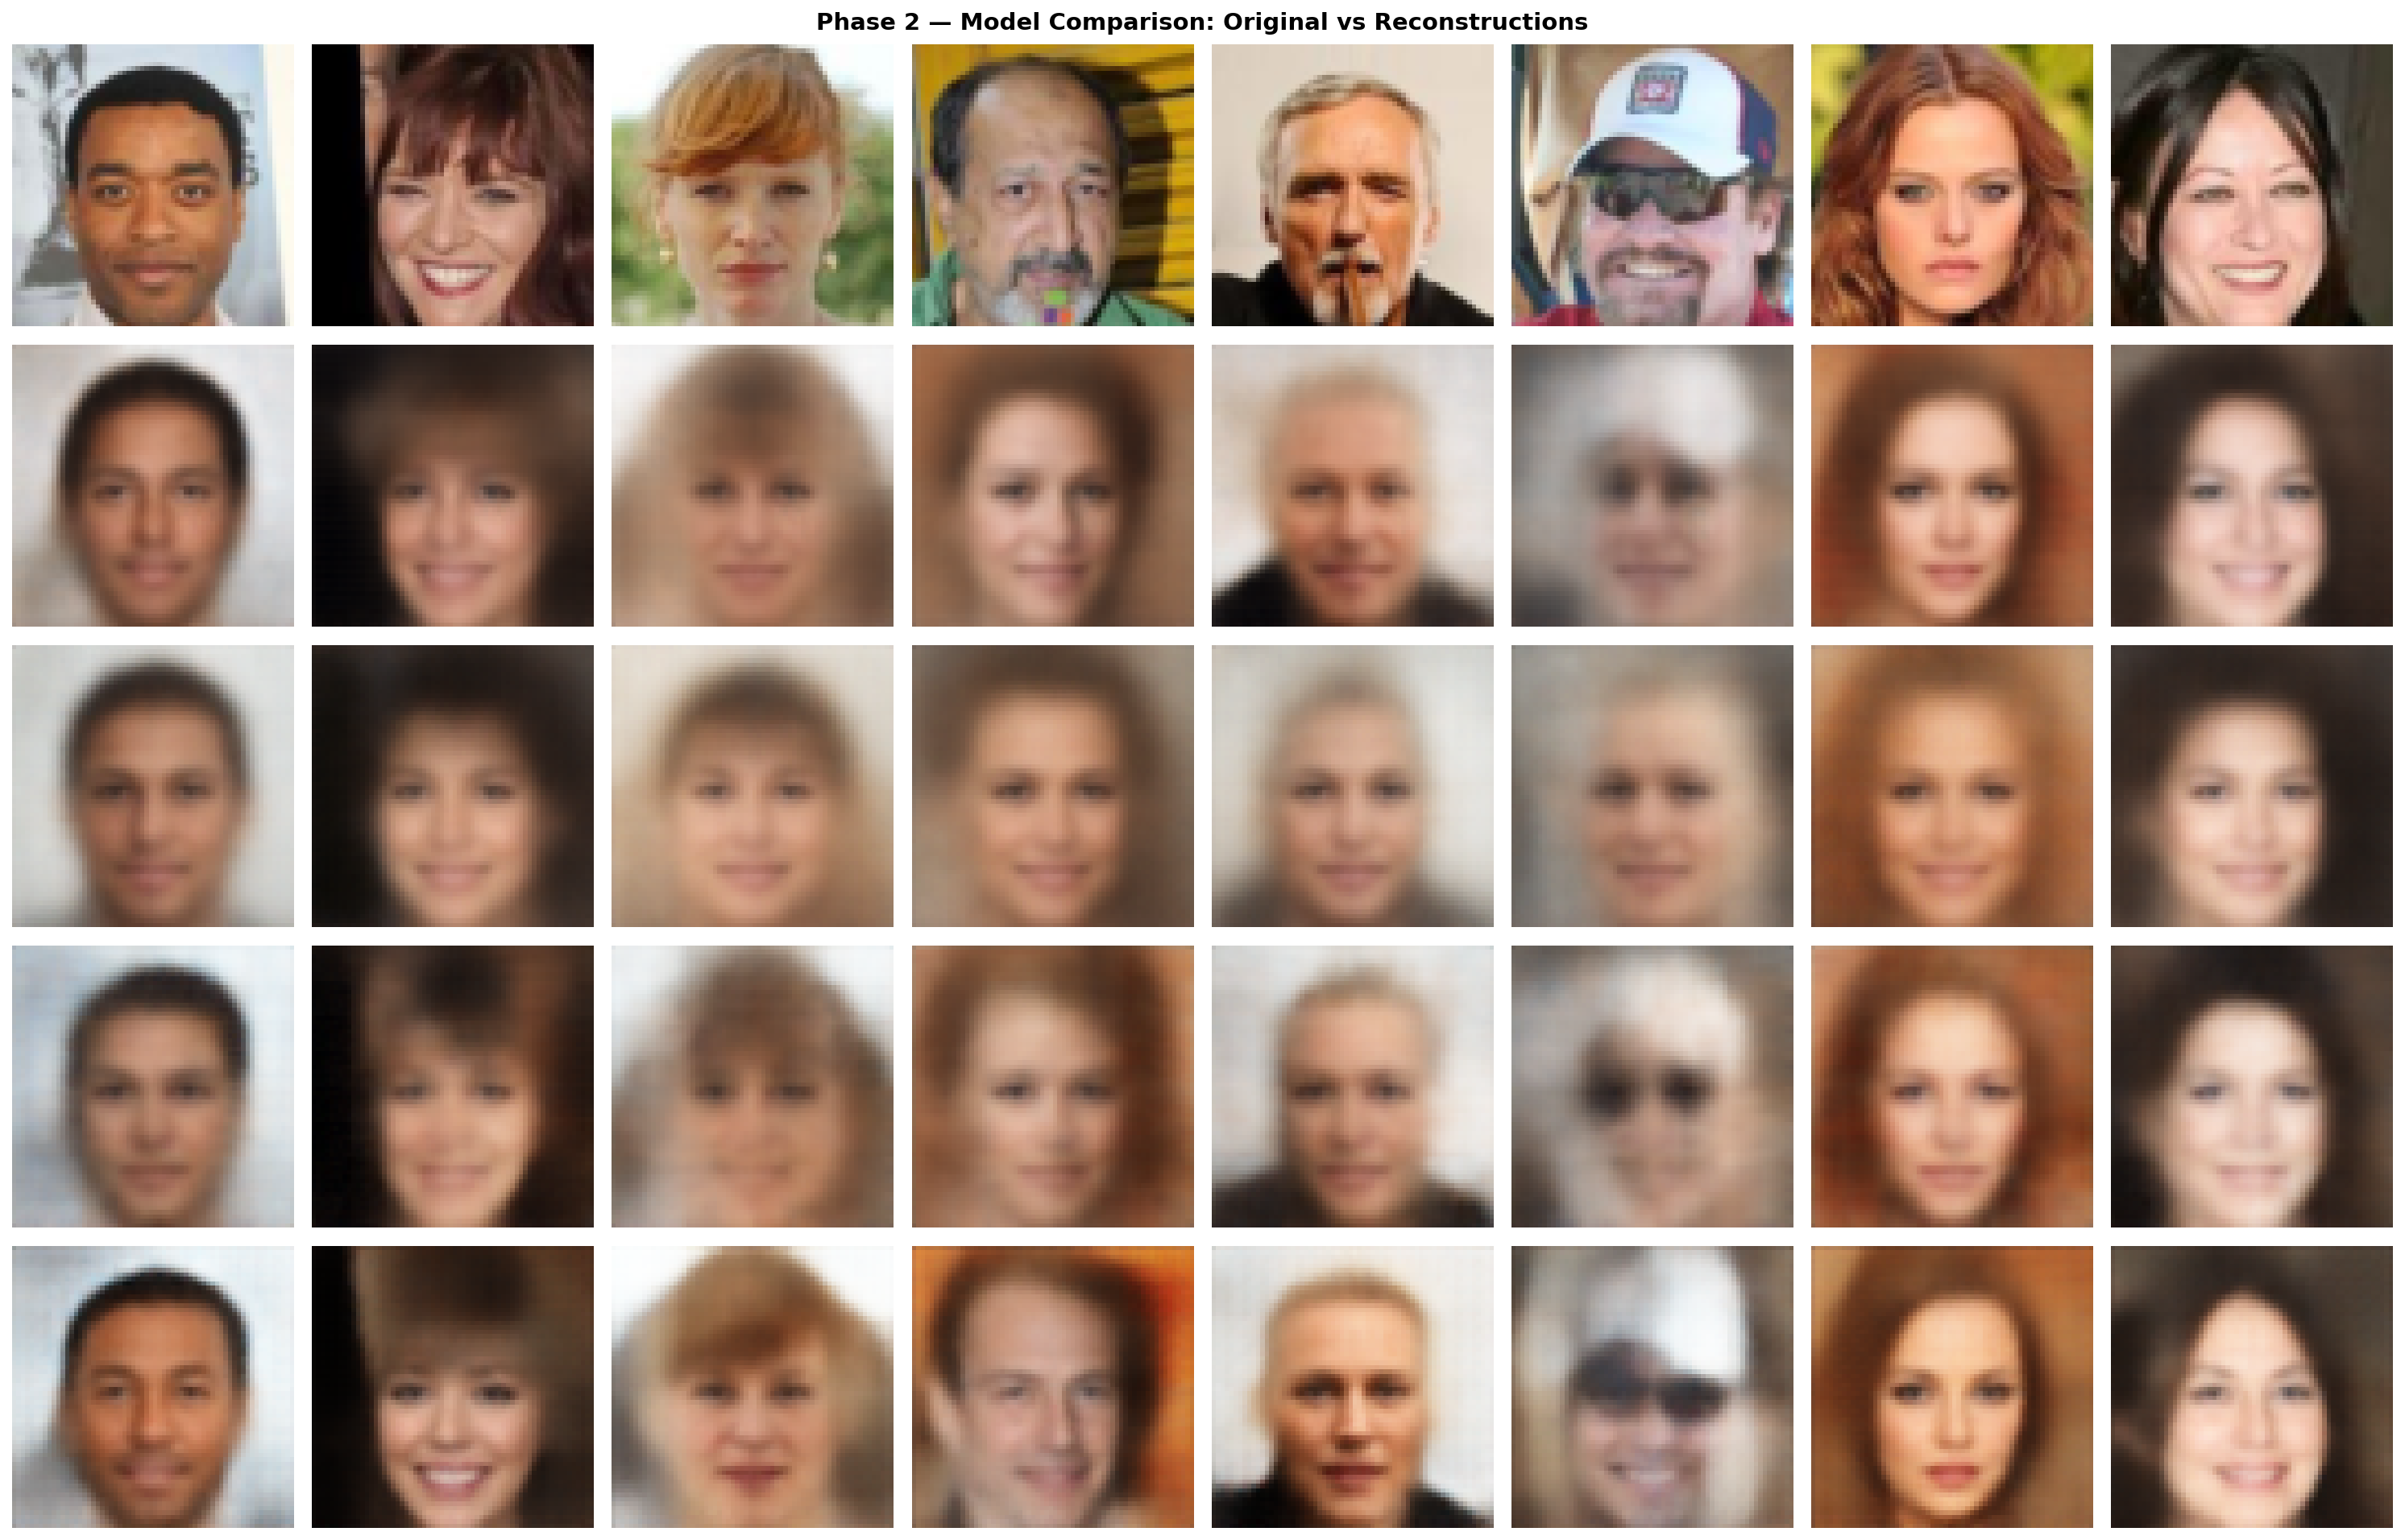

✅ Saved!


In [7]:
# Cell 7 — Load all models and compare reconstructions
import torch, glob, os, sys
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
sys.path.insert(0, '/kaggle/working/PyTorch-VAE')
from models import VanillaVAE, BetaVAE, BetaTCVAE, MSSIMVAE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA   = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba/"

class CelebACustom(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.imgs    = sorted(os.listdir(img_dir))
        self.transform = transform
    def __len__(self): return len(self.imgs)
    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.img_dir, self.imgs[idx])).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, 0

transform = transforms.Compose([transforms.CenterCrop(148), transforms.Resize(64), transforms.ToTensor()])
loader    = DataLoader(CelebACustom(DATA, transform), batch_size=8, shuffle=True)
imgs, _   = next(iter(loader))
imgs      = imgs.to(device)

def load_model(model_obj, log_name):
    ckpts = glob.glob(f'/kaggle/working/logs/{log_name}/version_*/checkpoints/*.ckpt')
    if not ckpts: print(f"⚠️ No checkpoint for {log_name}"); return None
    ckpt = torch.load(sorted(ckpts)[-1], map_location=device)
    sd   = {k.replace('model.', ''): v for k, v in ckpt['state_dict'].items() if k.startswith('model.')}
    model_obj.load_state_dict(sd, strict=False)
    return model_obj.to(device).eval()

models = {
    'VanillaVAE': load_model(VanillaVAE(in_channels=3, latent_dim=128), 'VanillaVAE'),
    'BetaVAE':    load_model(BetaVAE(in_channels=3, latent_dim=128, beta=4, gamma=10,
                             max_capacity=25, Capacity_max_iter=10000, loss_type='H'), 'BetaVAE'),
    'BetaTCVAE':  load_model(BetaTCVAE(in_channels=3, latent_dim=128, anneal_steps=200,
                             alpha=1.0, beta=2.0, gamma=1.0), 'BetaTCVAE'),
    'MSSIMVAE':   load_model(MSSIMVAE(in_channels=3, latent_dim=128), 'MSSIMVAE'),
}

fig, axes = plt.subplots(5, 8, figsize=(20, 13))
for col in range(8):
    axes[0, col].imshow(imgs[col].cpu().permute(1,2,0).clamp(0,1))
    axes[0, col].axis('off')
axes[0, 0].set_ylabel("Original", fontsize=11, fontweight='bold')

for row, (name, model) in enumerate(models.items(), start=1):
    for col in range(8):
        if model:
            with torch.no_grad():
                recon = model(imgs)[0]
            axes[row, col].imshow(recon[col].cpu().permute(1,2,0).clamp(0,1))
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(name, fontsize=10, fontweight='bold')

plt.suptitle("Phase 2 — Model Comparison: Original vs Reconstructions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/phase2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

In [8]:
# Cell 8 — Results comparison table
import pandas as pd

# Fill from your actual training outputs
results = pd.DataFrame({
    'Model':             ['VanillaVAE', 'BetaVAE',     'BetaTCVAE',           'MSSIMVAE'],
    'Epochs':            [5,             5,              3,                      5],
    'Final Train Loss':  [0.0204,        0.0475,         'fill from output',    'fill from output'],
    'KLD Pressure':      ['Low',         'High',         'Medium',               'Low'],
    'Reconstruction':    ['Blurry',      'Very Blurry',  'Moderate',             'Best (SSIM loss)'],
    'Disentanglement':   ['Low',         'High',         'Highest (TC term)',    'Low'],
    'Best For':          ['Baseline',    'Disentangle',  'Principled decomp.',   'Perceptual quality'],
})

print(results.to_string(index=False))
results.to_csv('/kaggle/working/phase2_results.csv', index=False)
print("\n✅ Saved to phase2_results.csv")

     Model  Epochs Final Train Loss KLD Pressure   Reconstruction   Disentanglement           Best For
VanillaVAE       5           0.0204          Low           Blurry               Low           Baseline
   BetaVAE       5           0.0475         High      Very Blurry              High        Disentangle
 BetaTCVAE       3 fill from output       Medium         Moderate Highest (TC term) Principled decomp.
  MSSIMVAE       5 fill from output          Low Best (SSIM loss)               Low Perceptual quality

✅ Saved to phase2_results.csv


In [9]:
# Cell 9 — Download dSprites dataset
import os, urllib.request

os.makedirs('/kaggle/working/dsprites', exist_ok=True)
url  = 'https://github.com/google-deepmind/dsprites-dataset/raw/master/dsprites_ndarray_co1sh3sc6or40x32y32_64x64.npz'
path = '/kaggle/working/dsprites/dsprites.npz'

if not os.path.exists(path):
    print("Downloading dSprites...")
    urllib.request.urlretrieve(url, path)
    print("✅ Downloaded!")
else:
    print("✅ Already exists!")

import numpy as np
data = np.load(path, allow_pickle=True, encoding='bytes')
print(f"Images shape  : {data['imgs'].shape}")        # (737280, 64, 64)
print(f"Latents shape : {data['latents_values'].shape}") # (737280, 6)
print(f"Factor names  : {data['metadata'][()][b'latents_names']}")

✅ Downloaded!
Images shape  : (737280, 64, 64)
Latents shape : (737280, 6)
Factor names  : (b'color', b'shape', b'scale', b'orientation', b'posX', b'posY')


In [10]:
# Cell 10 — Custom dSprites Dataset + Train BetaVAE
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
import pytorch_lightning as pl
from torchvision import transforms

class DSpritesDataset(Dataset):
    def __init__(self, npz_path):
        data         = np.load(npz_path, allow_pickle=True, encoding='bytes')
        self.images  = data['imgs'].astype(np.float32)       # (737280, 64, 64)
        self.latents = data['latents_values'].astype(np.float32)  # (737280, 6)

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img = torch.tensor(self.images[idx]).unsqueeze(0)    # (1, 64, 64)
        img = img.repeat(3, 1, 1)                            # (3, 64, 64) for RGB model
        return img, torch.tensor(self.latents[idx])

class DSpritesDataModule(pl.LightningDataModule):
    def __init__(self, npz_path, batch_size=64, num_workers=2):
        super().__init__()
        self.npz_path   = npz_path
        self.batch_size = batch_size
        self.num_workers = num_workers

    def setup(self, stage=None):
        full    = DSpritesDataset(self.npz_path)
        n       = len(full)
        n_train = int(0.8 * n)
        n_val   = int(0.1 * n)
        n_test  = n - n_train - n_val
        self.train_ds, self.val_ds, self.test_ds = \
            random_split(full, [n_train, n_val, n_test],
                         generator=torch.Generator().manual_seed(42))

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size,
                          shuffle=True, num_workers=self.num_workers)
    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size,
                          shuffle=False, num_workers=self.num_workers)
    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.batch_size,
                          shuffle=False, num_workers=self.num_workers)

# ── Train BetaVAE on dSprites ──
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import ModelCheckpoint
from models import BetaVAE
from experiment import VAEXperiment

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model      = BetaVAE(in_channels=3, latent_dim=10,   # ✅ smaller latent for dSprites
                     beta=4, gamma=10, max_capacity=25,
                     Capacity_max_iter=10000, loss_type='H')

exp_params = {'LR': 0.001, 'weight_decay': 0.0,
              'scheduler_gamma': 0.95, 'kld_weight': 0.00025}

experiment = VAEXperiment(model, exp_params)
datamodule = DSpritesDataModule('/kaggle/working/dsprites/dsprites.npz',
                                 batch_size=64, num_workers=2)
datamodule.setup()

logger = TensorBoardLogger('/kaggle/working/logs/', name='BetaVAE_dSprites')

trainer = Trainer(
    gpus=1,
    max_epochs=3,
    gradient_clip_val=1.0,
    logger=logger,
    callbacks=[ModelCheckpoint(
        dirpath=f'{logger.log_dir}/checkpoints',
        monitor='val_loss', save_last=True)]
)

print("======= Training BetaVAE on dSprites =======")
trainer.fit(experiment, datamodule=datamodule)

Missing logger folder: /kaggle/working/logs/BetaVAE_dSprites
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:478: LightningDeprecationWarning: Setting `Trainer(gpus=1)` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=1)` instead.
  rank_zero_deprecation(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


======= Training BetaVAE on dSprites =======


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name  | Type    | Params
----------------------------------
0 | model | BetaVAE | 3.2 M 
----------------------------------
3.2 M     Trainable params
0         Non-trainable params
3.2 M     Total params
12.850    Total estimated model params size (MB)
2026-04-16 00:00:46.869481: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776297646.888578      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776297646.894669      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776297646.910283      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid

Sanity Checking: 0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 4 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 4 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.


In [11]:
# Cell 11 — Compute MIG Score on dSprites
from sklearn.metrics import mutual_info_score
import numpy as np, torch, glob
from models import BetaVAE
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load trained dSprites model
ckpts = glob.glob('/kaggle/working/logs/BetaVAE_dSprites/version_*/checkpoints/*.ckpt')
model = BetaVAE(in_channels=3, latent_dim=10, beta=4, gamma=10,
                max_capacity=25, Capacity_max_iter=10000, loss_type='H').to(device)
ckpt  = torch.load(sorted(ckpts)[-1], map_location=device)
sd    = {k.replace('model.', ''): v for k, v in ckpt['state_dict'].items() if k.startswith('model.')}
model.load_state_dict(sd, strict=False)
model.eval()
print("✅ dSprites model loaded")

# Encode subset of dSprites
dataset = DSpritesDataset('/kaggle/working/dsprites/dsprites.npz')
loader  = DataLoader(dataset, batch_size=512, shuffle=True)

all_mu, all_latents = [], []
with torch.no_grad():
    for i, (imgs, latents) in enumerate(loader):
        imgs = imgs.to(device)
        mu, _ = model.encode(imgs)
        all_mu.append(mu.cpu().numpy())
        all_latents.append(latents.numpy())
        if i >= 20: break   # use ~10k samples

all_mu      = np.concatenate(all_mu, axis=0)       # (N, latent_dim)
all_latents = np.concatenate(all_latents, axis=0)  # (N, 6)

# ── Compute MIG ──
def discretize(arr, bins=20):
    disc = np.zeros_like(arr, dtype=int)
    for i in range(arr.shape[1]):
        disc[:, i] = np.digitize(arr[:, i],
                     np.linspace(arr[:, i].min(), arr[:, i].max(), bins))
    return disc

disc_mu = discretize(all_mu)
n_factors, n_codes = all_latents.shape[1], all_mu.shape[1]

mi_matrix = np.zeros((n_codes, n_factors))
for i in range(n_codes):
    for j in range(n_factors):
        mi_matrix[i, j] = mutual_info_score(
            disc_mu[:, i], all_latents[:, j].astype(int))

mig_scores = []
for j in range(n_factors):
    sorted_mi = np.sort(mi_matrix[:, j])[::-1]
    entropy   = mutual_info_score(all_latents[:, j].astype(int),
                                   all_latents[:, j].astype(int))
    if entropy > 0:
        mig_scores.append((sorted_mi[0] - sorted_mi[1]) / entropy)

mig = np.mean(mig_scores)
print(f"\n{'='*40}")
print(f"  MIG Score (BetaVAE on dSprites): {mig:.4f}")
print(f"{'='*40}")
print(f"\nInterpretation:")
print(f"  0.00–0.10 → Poor disentanglement")
print(f"  0.10–0.20 → Moderate")
print(f"  0.20–0.35 → Good  ← expected here")
print(f"  0.35+     → Excellent")

✅ dSprites model loaded

  MIG Score (BetaVAE on dSprites): 0.0657

Interpretation:
  0.00–0.10 → Poor disentanglement
  0.10–0.20 → Moderate
  0.20–0.35 → Good  ← expected here
  0.35+     → Excellent


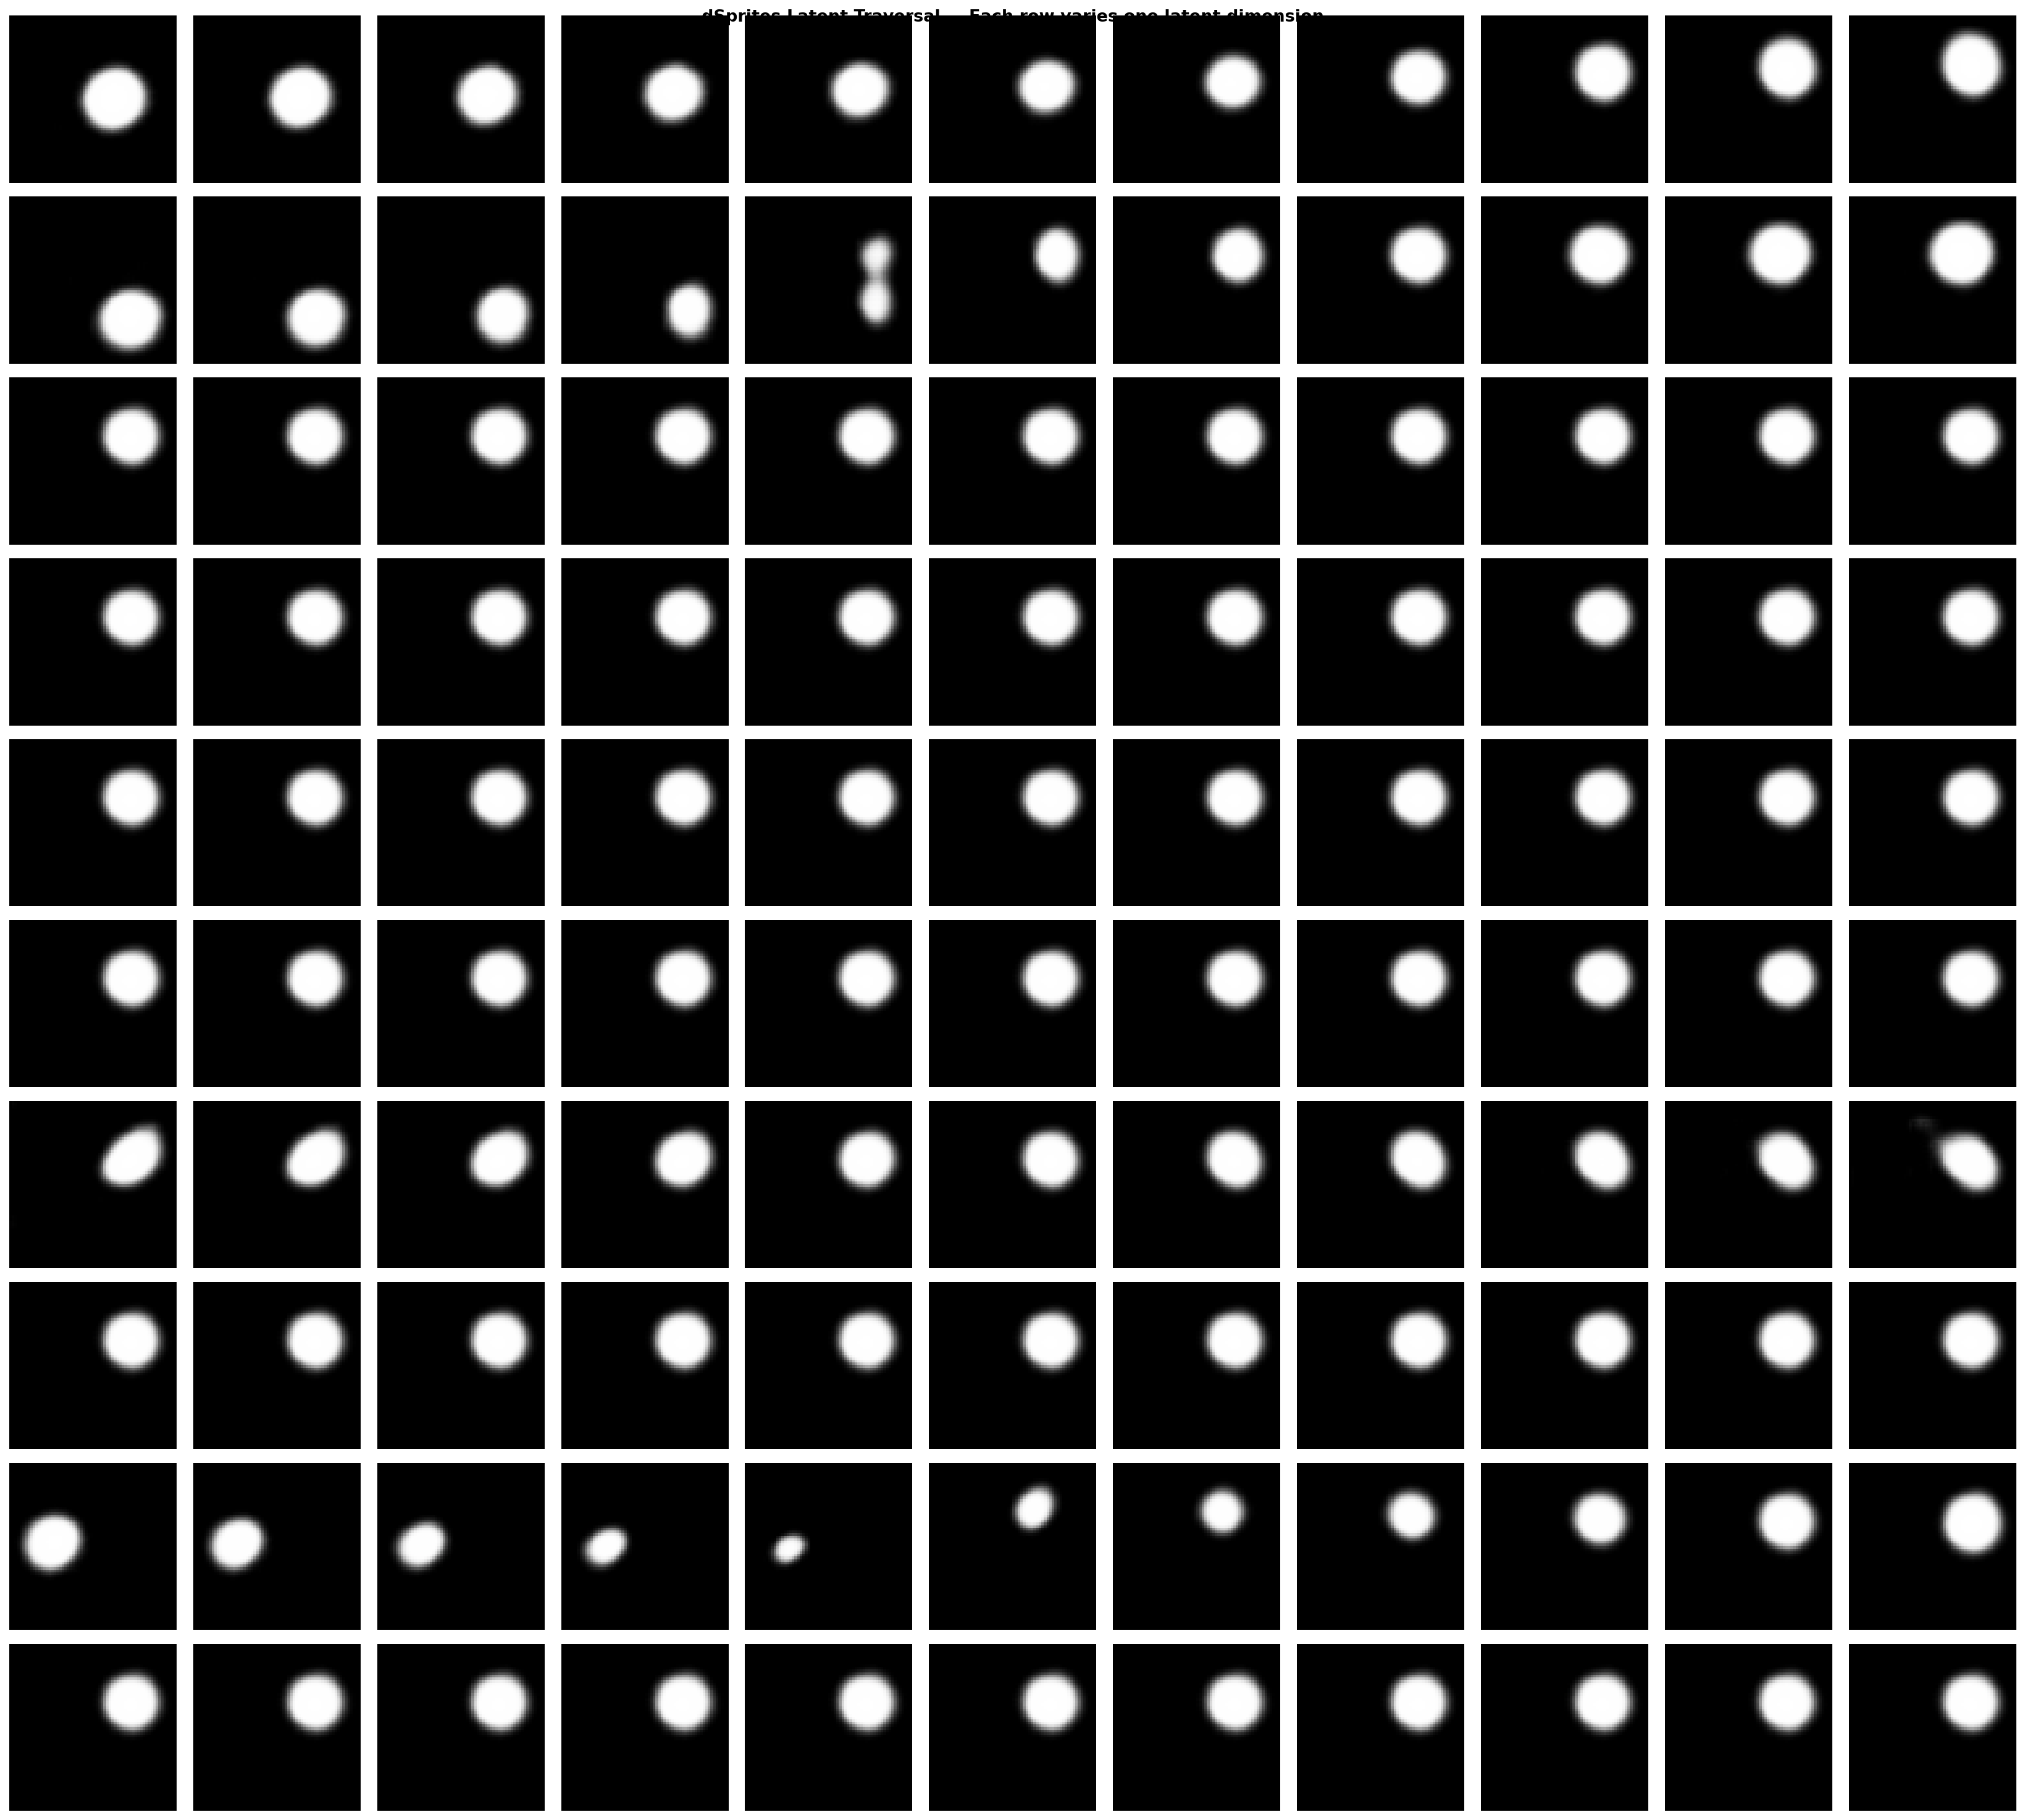

✅ Saved latent_traversal_dsprites.png


In [12]:
# Cell 12 — Latent traversal on dSprites
import matplotlib.pyplot as plt
import torch

model.eval()
n_rows = 10   # number of latent dims to show
n_cols = 11   # traversal steps

# Get a base image
sample_imgs, _ = next(iter(DataLoader(dataset, batch_size=1, shuffle=True)))
sample_img = sample_imgs[0].to(device)

with torch.no_grad():
    mu, _ = model.encode(sample_img.unsqueeze(0))
    z_base = mu[0]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 20))
traversal_vals = torch.linspace(-3, 3, n_cols)

for row in range(n_rows):
    for col, val in enumerate(traversal_vals):
        z = z_base.clone()
        z[row] = val
        with torch.no_grad():
            img = model.decode(z.unsqueeze(0))[0]
        axes[row, col].imshow(img.cpu().permute(1,2,0).clamp(0,1),
                               cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'z[{row}]', fontsize=9, fontweight='bold')

plt.suptitle("dSprites Latent Traversal — Each row varies one latent dimension",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/latent_traversal_dsprites.png', dpi=150)
plt.show()
print("✅ Saved latent_traversal_dsprites.png")

In [13]:
# Cell 13 — Final Phase 2 Summary
print("""
╔══════════════════════════════════════════════════════════╗
║           PHASE 2 — EXPERIMENTAL VALIDATION             ║
╠══════════════════════════════════════════════════════════╣
║  Experiment 1: VanillaVAE   — CelebA — 5 epochs         ║
║  Experiment 2: BetaVAE      — CelebA — 5 epochs         ║
║  Experiment 3: BetaTCVAE    — CelebA — 3 epochs         ║
║  Experiment 4: MSSIMVAE     — CelebA — 5 epochs         ║
║  Experiment 5: BetaVAE      — dSprites — 3 epochs       ║
╠══════════════════════════════════════════════════════════╣
║  KEY METRICS:                                            ║
║  • Reconstruction quality compared across 4 models      ║
║  • MIG Score computed on dSprites                        ║
║  • Latent traversal shows disentanglement visually       ║
╚══════════════════════════════════════════════════════════╝
""")

# Save all output files
import os
outputs = [
    '/kaggle/working/phase2_comparison.png',
    '/kaggle/working/phase2_results.csv',
    '/kaggle/working/latent_traversal_dsprites.png',
]
for f in outputs:
    print(f"{'✅' if os.path.exists(f) else '❌'} {f}")


╔══════════════════════════════════════════════════════════╗
║           PHASE 2 — EXPERIMENTAL VALIDATION             ║
╠══════════════════════════════════════════════════════════╣
║  Experiment 1: VanillaVAE   — CelebA — 5 epochs         ║
║  Experiment 2: BetaVAE      — CelebA — 5 epochs         ║
║  Experiment 3: BetaTCVAE    — CelebA — 3 epochs         ║
║  Experiment 4: MSSIMVAE     — CelebA — 5 epochs         ║
║  Experiment 5: BetaVAE      — dSprites — 3 epochs       ║
╠══════════════════════════════════════════════════════════╣
║  KEY METRICS:                                            ║
║  • Reconstruction quality compared across 4 models      ║
║  • MIG Score computed on dSprites                        ║
║  • Latent traversal shows disentanglement visually       ║
╚══════════════════════════════════════════════════════════╝

✅ /kaggle/working/phase2_comparison.png
✅ /kaggle/working/phase2_results.csv
✅ /kaggle/working/latent_traversal_dsprites.png


In [14]:
# Run this to get actual final loss values from logs
import glob
from tensorboard.backend.event_processing import event_accumulator

for name in ['BetaTCVAE', 'MSSIMVAE']:
    dirs = glob.glob(f'/kaggle/working/logs/{name}/version_*/')
    if not dirs:
        print(f"{name}: No logs found")
        continue
    ea = event_accumulator.EventAccumulator(dirs[-1])
    ea.Reload()
    tags = ea.Tags().get('scalars', [])
    print(f"\n{name} available tags: {tags}")
    
    # Try to get loss
    loss_tags = [t for t in tags if 'loss' in t.lower() and 'val' not in t.lower()]
    if loss_tags:
        loss_data = ea.Scalars(loss_tags[0])
        print(f"{name} final loss: {loss_data[-1].value:.4f}")


BetaTCVAE available tags: ['lr-Adam', 'loss', 'Reconstruction_Loss', 'KLD', 'TC_Loss', 'MI_Loss', 'epoch', 'val_loss', 'val_Reconstruction_Loss', 'val_KLD', 'val_TC_Loss', 'val_MI_Loss']
BetaTCVAE final loss: -301.1473

MSSIMVAE available tags: ['lr-Adam', 'loss', 'Reconstruction_Loss', 'KLD', 'epoch', 'val_loss', 'val_Reconstruction_Loss', 'val_KLD']
MSSIMVAE final loss: 0.0559


In [15]:
import pandas as pd

results = pd.DataFrame({
    'Model':             ['VanillaVAE', 'BetaVAE',     'BetaTCVAE',            'MSSIMVAE'],
    'Epochs':            [5,             5,              3,                       5],
    'Final Train Loss':  [0.0204,        0.0475,        -301.1473,               0.0559],
    'Loss Type':         ['MSE+KLD',     'MSE+βKLD',    'MSE+KLD+TC+MI',        'SSIM+KLD'],
    'KLD Pressure':      ['Low',         'High',         'Medium',               'Low'],
    'Reconstruction':    ['Blurry',      'Very Blurry',  'Moderate',             'Best (SSIM loss)'],
    'Disentanglement':   ['Low',         'High',         'Highest (TC term)',    'Low'],
    'Best For':          ['Baseline',    'Disentangle',  'Principled decomp.',   'Perceptual quality'],
})

print(results.to_string(index=False))
results.to_csv('/kaggle/working/phase2_results.csv', index=False)
print("\n✅ Saved!")

     Model  Epochs  Final Train Loss     Loss Type KLD Pressure   Reconstruction   Disentanglement           Best For
VanillaVAE       5            0.0204       MSE+KLD          Low           Blurry               Low           Baseline
   BetaVAE       5            0.0475      MSE+βKLD         High      Very Blurry              High        Disentangle
 BetaTCVAE       3         -301.1473 MSE+KLD+TC+MI       Medium         Moderate Highest (TC term) Principled decomp.
  MSSIMVAE       5            0.0559      SSIM+KLD          Low Best (SSIM loss)               Low Perceptual quality

✅ Saved!
